# 1. Generate 2D dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def Show_data2D(x):
    plt.plot(np.arange(L),x[0, :, 0], label='sample 0', c='r')
    plt.plot(np.arange(L,2*L),x[1, :, 0], label='sample 1', c='y')
    plt.plot(np.arange(2*L,3*L),x[2, :, 0], label='sample 2', c='b')
    plt.plot(np.arange(L),x[0, :, 1], label='sample 0', c='r')
    plt.plot(np.arange(L,2*L),x[1, :, 1], label='sample 1', c='y')
    plt.plot(np.arange(2*L,3*L),x[2, :, 1], label='sample 2', c='b')
    
    plt.legend()
    plt.title("Time series (sample 0-1-2)")
    plt.show()

In [4]:
# random seed for reproducibility
np.random.seed(12345)

jump = lambda drift1, drift2, std1, std2: [int(np.random.normal(drift1,std1)), int(np.random.normal(drift2, std2))]
# rumore non lineare????

In [5]:
def pattern(i,z,a):
    return [int(a*np.cos((np.pi*i)/z)), int(a*np.sin((np.pi*i)/z))]

In [6]:
# pattern parameters: Z=nr of steps, A=amplitude
Z=12
A=500

N=10000
L=60

DX1 = 50 
bias1 = 5 
DX2 = 20
bias2 = 10

y = np.zeros((N, 2))
x = np.zeros((N,L,2))

for i in range(N):
    if i>0: 
        jump0, jump1 = jump(bias1, bias2, DX1, DX2)
        x[i][0][0] = x[i-1][-1][0] + jump0 
        x[i][0][1] = x[i-1][-1][1] + jump1
    
    for j in range(1,L):
        jump0, jump1 = jump(bias1, bias2, DX1, DX2)
        x[i][j][0] = x[i][j-1][0] + jump0
        x[i][j][1] = x[i][j-1][1] + jump1
        
    y[i][0] = i%3 # assign class labels (0,1,2)
    y[i][1] = i%3
   
    if y[i][0]>0:
        j0 = np.random.randint(0,L-1-Z) 
        sign = 3-2*y[i][0] 
        for j in range(Z): 
            x[i][j0+j][0] += sign*pattern(j,Z,A)[0]
            x[i][j0+j][1] += sign*pattern(j,Z,A)[1]

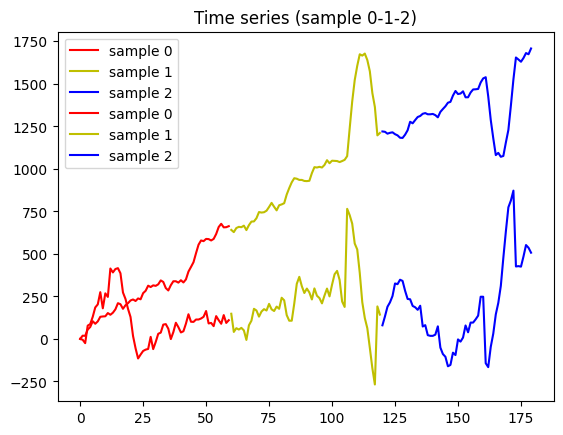

In [7]:
# visualizing data
Show_data2D(x)

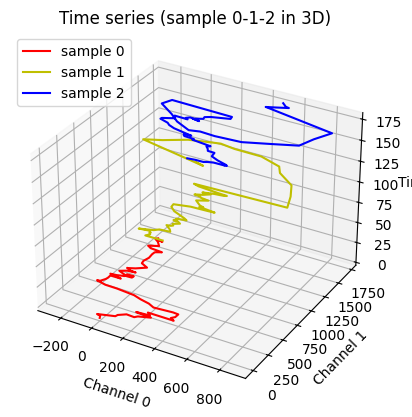

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def Show_data2D_3D(x, L):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    colors = ['r', 'y', 'b']

    for i in range(3):
        t = np.arange(i * L, (i + 1) * L)

        ax.plot(
            x[i, :, 0],   # x = channel 0
            x[i, :, 1],   # y = channel 1
            t,            # z = time (stacked)
            color=colors[i],
            label=f"sample {i}"
        )

    ax.set_xlabel("Channel 0")
    ax.set_ylabel("Channel 1")
    ax.set_zlabel("Time")

    ax.set_title("Time series (sample 0-1-2 in 3D)")
    ax.legend()

    plt.show()

Show_data2D_3D(x, L)